In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('../data/city_day.csv')
print("Shape of data:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of data: (29531, 16)

First 5 rows:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
print("Column names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nBasic statistics:")
df.describe()

Column names:
 ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data types:
 City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

Basic statistics:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [4]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})

print(missing_df[missing_df['Missing Values'] > 0])

            Missing Values  Percentage
PM2.5                 4598   15.570079
PM10                 11140   37.723071
NO                    3582   12.129626
NO2                   3585   12.139785
NOx                   4185   14.171549
NH3                  10328   34.973418
CO                    2059    6.972334
SO2                   3854   13.050692
O3                    4022   13.619586
Benzene               5623   19.041008
Toluene               8041   27.229014
Xylene               18109   61.322001
AQI                   4681   15.851139
AQI_Bucket            4681   15.851139


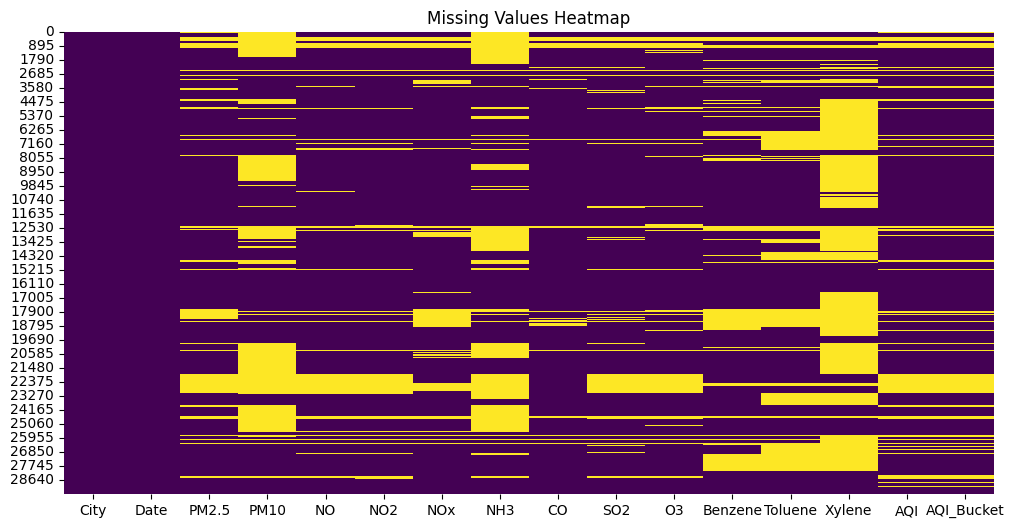

In [5]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [6]:
# Xylene has 61% missing - useless, drop it
df = df.drop(columns=['Xylene'])
print("Dropped Xylene!")
print("New shape:", df.shape)

Dropped Xylene!
New shape: (29531, 15)


In [7]:
# Fill missing numbers with median of that column
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Drop rows where AQI is still missing
df = df.dropna(subset=['AQI', 'AQI_Bucket'])

print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nNew shape:", df.shape)

Missing values after cleaning:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

New shape: (24850, 15)


In [8]:
# Convert Date from text to actual date format
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

print("Date columns added!")
df[['Date', 'Year', 'Month', 'Day']].head()

Date columns added!


,Date,Year,Month,Day
28,2015-01-29,2015,1,29
29,2015-01-30,2015,1,30
30,2015-01-31,2015,1,31
31,2015-02-01,2015,2,1
32,2015-02-02,2015,2,2


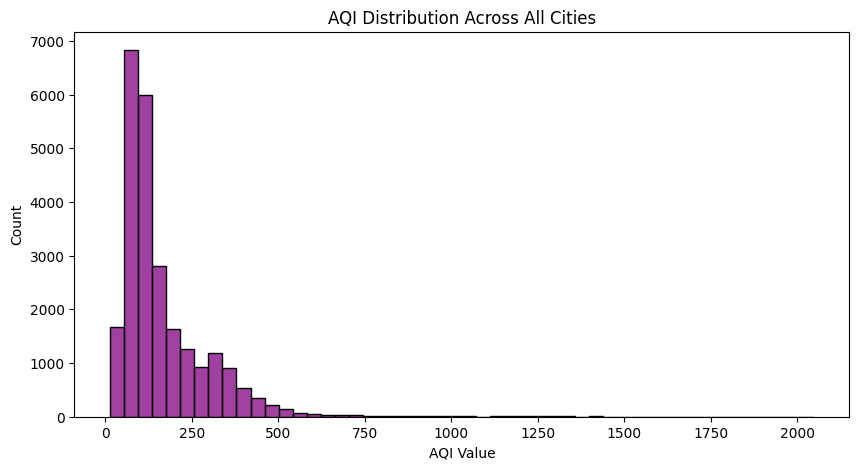

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df['AQI'], bins=50, color='purple')
plt.title('AQI Distribution Across All Cities')
plt.xlabel('AQI Value')
plt.ylabel('Count')
plt.show()

C:\Users\Sachin Singh\AppData\Local\Temp\ipykernel_500\988012420.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_aqi.index, y=city_aqi.values, palette='Reds_r')


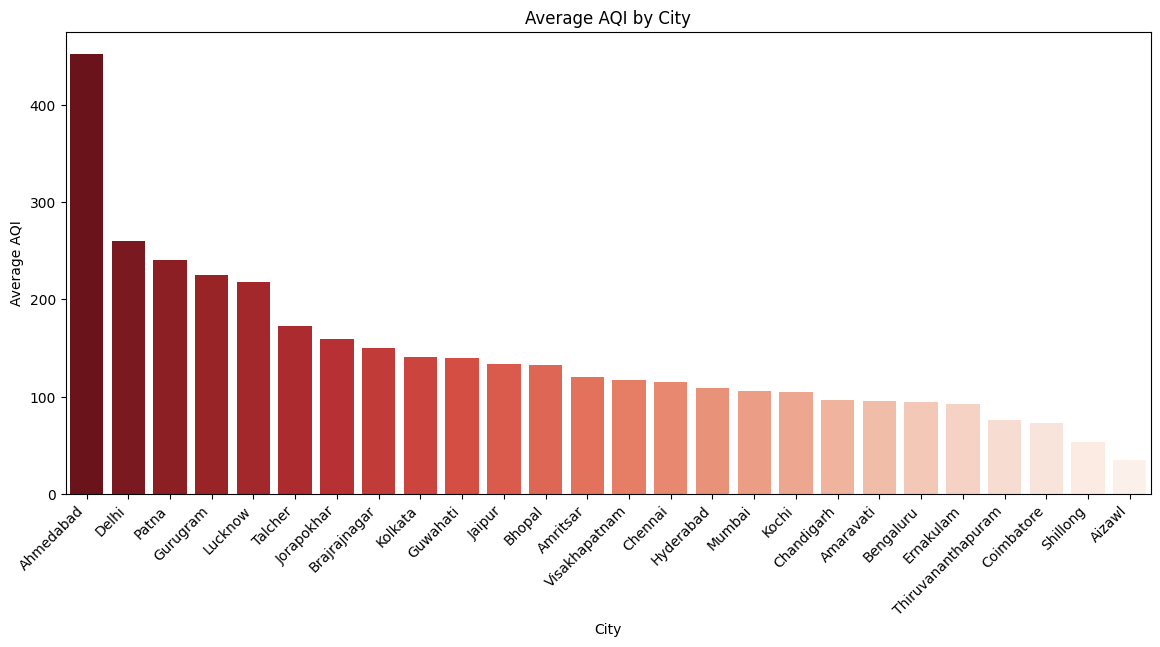

In [10]:
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=city_aqi.index, y=city_aqi.values, palette='Reds_r')
plt.title('Average AQI by City')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average AQI')
plt.show()

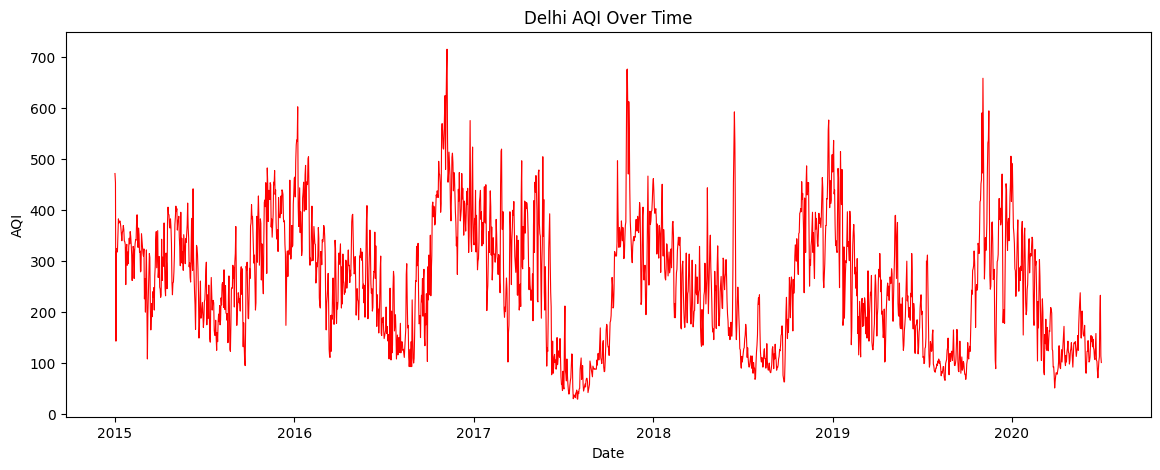

In [11]:
delhi = df[df['City'] == 'Delhi'].sort_values('Date')

plt.figure(figsize=(14, 5))
plt.plot(delhi['Date'], delhi['AQI'], color='red', linewidth=0.8)
plt.title('Delhi AQI Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.show()